**5. Attention Is All You Need: An easy and swift dissection**  
Access to AI can be achieved from two perspectives: algorithmic foundations and practical engineering. Transformer is the cornerstone of all large language models (LLM), including GPT and deepseek. Its core innovation points are Transformer architecture and Self-Attention mechanism. Sequence Transduction model, like DNA sequence and natural language text, are based on RNN(few CNN) before the Transformer.  
Natural language processing's transition from rule-based methods to statistical models has driven the birth of search engines like Google (see a practice project [localLitFinder](https://github.com/ruiliuacd/localLitFinder) ). The grammatical correctness of a sentence can be evaluated in terms of probability. A sentence S, for example, consist of words w1,w2,w3,... in order. Based on statistics from large human language corpora, we can calculate the probability of such word combinations. If the probability is very low, the sentence is likely unreasonable or incorrect. The appearance of next word can be evaluated probabilistically, and it is usually influenced by the words that precede it or context. Statistical model methods convert web pages or articles into vectors using TF-IDF weighting of all terms in a predefined vocabulary. In LLM, through embedding, all entities, including words, sentences, images, and other data forms, are also converted into vectors (usually 512 or 1024 dimensions), with each dimension potentially capturing different features of the entities. With vectors, people can do a lot of mathematic operations that could relect their true semantics. Then it become understandable to computer machine. A typical sequence transduction task is translation. e.g. translate "我爱水课" into "I love easy courses". Compare to FNN, RNN do such task with improvements that capture word order/contextual information and allow varable length input.
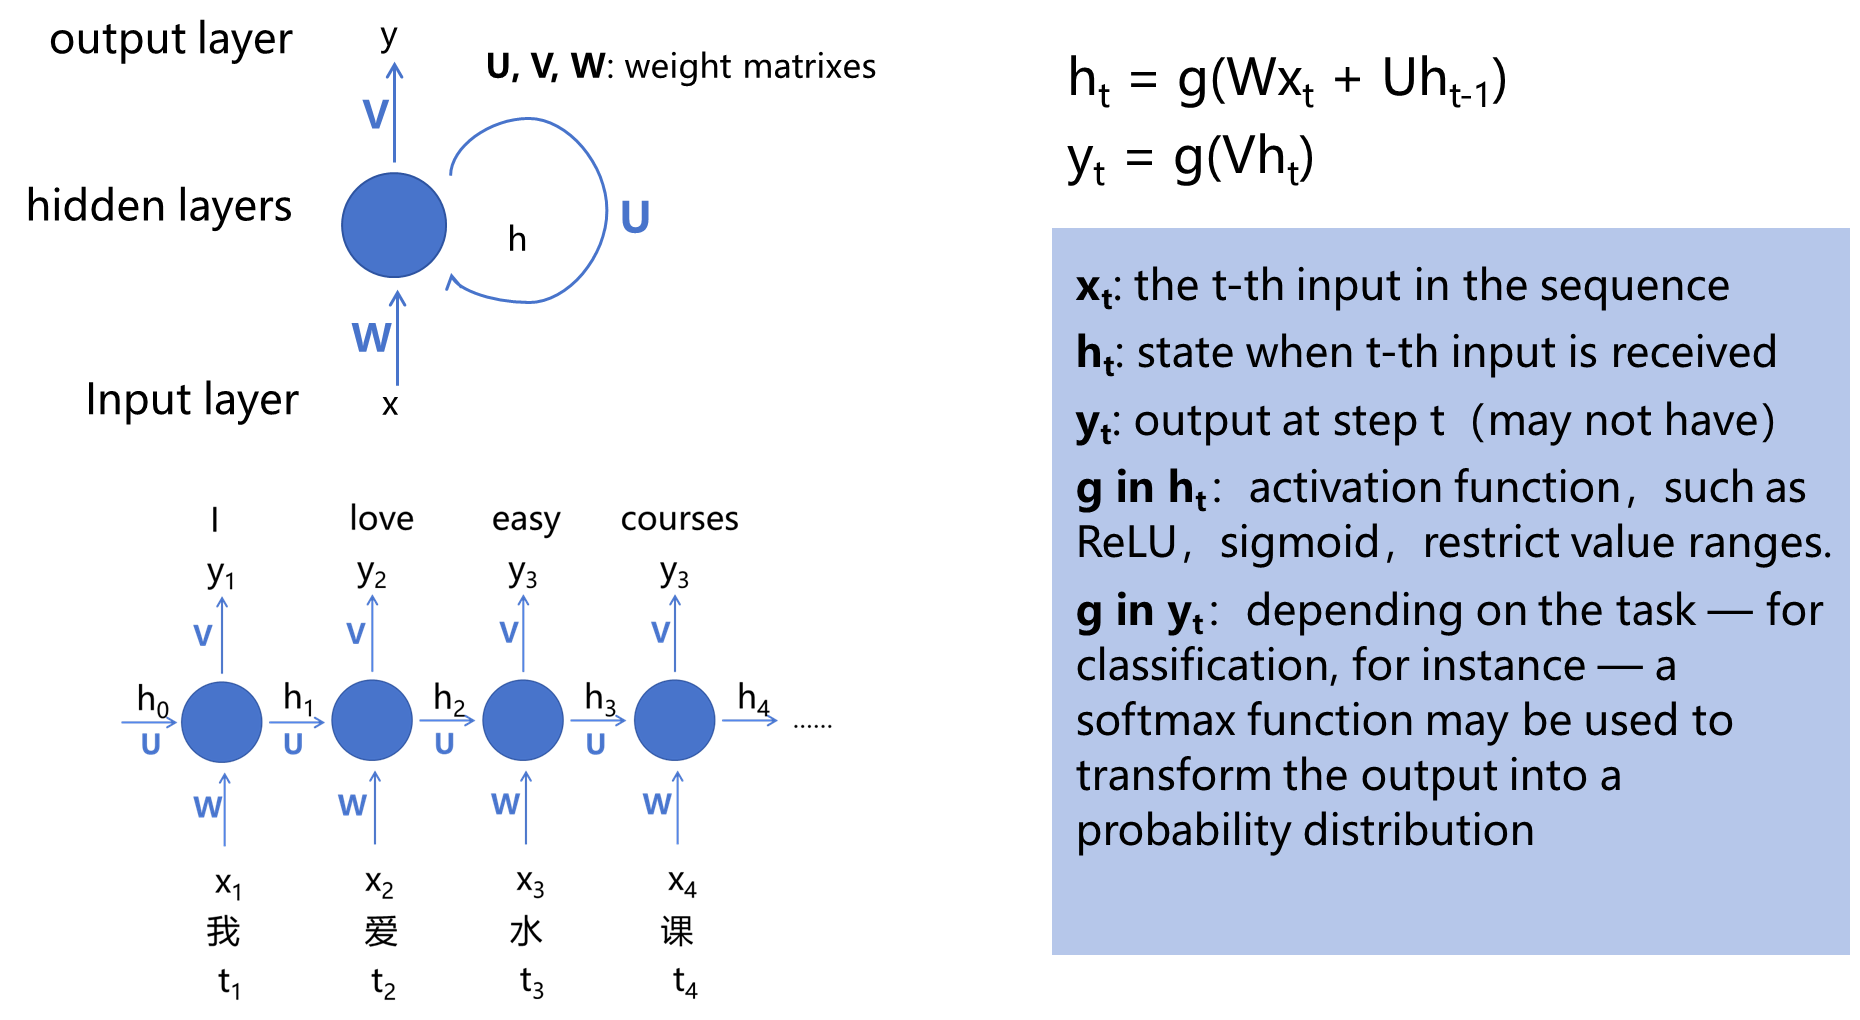  
Fig. 5.1 Recurrent Neural Network (upper) and exhibit different states of the same RNN through time during translation task (lower).  
As shown in Fig. 5.1, the words "我爱水课" input into RNN one by one. In step 1, the model takes "我" (its vector) as input, and the resulting hidden state h1 will be taken as a recurrently input to the network when step 2 takes "爱" as input together. The actual output of step 1, y<sub>1</sub> = (h1 product weight matrix V then go across activation function). In most time, each input don't have to have a output. i.e. each output don't directly map to one input. Encoder and decoder architecture were inroduced to replace output generation during every step taking input. i.e. Encoder receives input recurrently and system use the final hidden state output, e.g. h<sub>4</sub>, put it into decoder and generate output recurrently. Using decoder to decode this final hidden output through another neural network to produce output one by one. In this way, the final hidden state, h<sub>4</sub> here, also incorporate context and input order information. In this way, the number of outputs doesn't have to be the same number of inputs.
Transformer adopts this encoder-decoder architecture with using self-attention mechanisms in both encoder and decoder instead of RNN. The attention mechanism could distinguish between words with multiple meanings in different context. e.g. "水" is not a noun that closer to "oil","liquid" or "drink" here, but rather a adjective to describe the "courses", through their specific context. Transformer's architecture thoroughly abandons RNN, as its recursive structure precludes parallelization, and instead uses self-attention mechanisms to perceive context and positional order.
Basically, it first tokenized the text and converts each token into embedding, i.e. high-dimensional (e.g. 512) vector (blue slash in rectangle in Fig. 5.2). Then using the following formula calculate the element values for every dimension i for each token position produce position vectors of the same dimensionality with embedding vectors (red slash draw in Fig. 5.2). Add the two vectors for each token to form the final input embedding matrix, which encodes both positional information and the initial semantic meaning (Fig. 5.2 left with both red and blue).  
 
> *PE*<sub>(*pos,*2*i*)</sub> = *sin*(*pos/*10000<sup>2*i/d*</sup>model)  
> *PE*<sub>(*pos,*2*i*+1)</sub> = *cos*(*pos/*10000<sup>2*i/d*</sup>model )

Second step, using this final embedding matrix product weight matrix (Wq,Wk,Wv) respectively, we obtain the Query, Key and Value matrices (Query matrix and Key Matrix demostrated in the right top of Fig. 5.2). In order to let each token 'see' the context information, we dotproduct Query matrix and Key matrix. This operation is equivalent to letting each token to inquire about all other tokens, like do you have anything useful for me? Each score in the 4×4 attention matrix tells us how well the other tokens match this query token to help create a new representation for this query token. These processes are actually finished in multi-head.
![alt text](res/note02.jpg)  
Fig. 5.2 Each rectangular bar represents a vector in a matrix.  
Finally, using this attention matrix product the Value matrix, we get the matrix contain vectors of specific contextual meaning.

Just grasp the gist on how it works- as in most cases we just do the application works, simply leverage existing packages. Below We'll implement RAG (Retrieval-Augmented Generation) using the langchain library.

**6. Using RAG tech based on langchain to implement a LLM application with a private knowledge base**  
When develpoing applications, we commonly use already trained LLMs. We can attach an external private knowledge base and develop applications to utilize the LLM with addtional query from private knowledge to support our business tasks. Basical this process vectorize the private knowledge content — known as embedding — to create a vector database. Later, when we query the LLM application, the query will first retrieve relevant knowledge from the private database and both the query and the retrived content are submitted to the LLM. This is basically the RAG technology.  
Step 1  
Loading data from e.g. pdf, word, webpages, csv, json, md files or dirs using langchain.

In [ ]:
from langchain_core.documents import Document
#loading data，store information include content and source
document = Document(
    page_content="Hello, world!",
    metadata={"source":"https://example.com"}
)
# e.g. loading pure text
from langchain_community.document_loaders import TextLoader,CSVloader
text_loader=TextLoader(r"/path/to/my.txt",encoding="utf-8")
document1=text_loader.load()
# loading csv file 
csv_loader=CSVloader(r"/path/to/my.csv",encoding="utf-8")
document2=csv_loader.load()
print(type(documents[0]))

After loading the text into memory, we need to split it before feeding it into the LLM, because the model has a limited context window (short memory).  
Step 2. split text

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text="Trypanosomatids are a family of parasitic protists that includes Leishmania, Crithidia,and Trypanosoma species and belongs to the class Kinetoplastida. They are of medical importance as the causative agents of the human diseases leishmaniasis, trypanosomiasis, and Chagas disease"
splitter=RecursiveCharacterTextSplitter(chunk_size=15,chunk_overlap=3,separators=["\n\n","\n"," ",".",",","，","。",""])
chunks=splitter.split_text(text)
print(chunks)

Step 3. embedding the sentence

In [ ]:
from sentence_transformers import SentenceTransformer
model= SentenceTransformer("models/AI-ModelScope/bge-large-zh-v1___5")# GPU would accelerate
texts=["They are of medical importance","Members of this family rely on flagella for movement and survival in either their vertebrate host or insect vector","For example,","the flagellated promastigote form of Leishmania mexicana, which inhabits blood-feeding phlebotomine sand flies"]
embeddings=model.encode(texts)
print(embeddings)
print(embeddings.shape)

from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity(embeddings[0],embeddings[1])

Step 4. Store the knowledge into vector databases  
When a user asked a question, first find the relevant texts through check the distance between corresponding embedding vectors.

In [ ]:
embeddings=np.array(embeddings)
index=faiss.IndexFlatIP(1024)
index.add(embeddings)# store the ‘sentence’ into vector database
#Then after asking a question, it can find the relevant sentences
query_embedding=model.encode(["what is Trypanosomatids?"])
D,I = index.search(query_embedding,k=3)
print("the index of the similar sentences",I)
print("distance",D)

With such private knowledge database, when asking a question need the information that contained in your private documents, rather in the general LLM, the application would first retrieve your private content then call LLM.

In [ ]:
from langchain_community.vectorstores import FAISS # 
from langchain_huggingface import HuggingFaceEmbeddings# Hugging Face embedding model
from langchain_community.document_loaders import TextLoader 
from langchain.text_splitter import RecursiveCharacterTextSplitter
loader = TextLoader(r"./data/companydata.txt", encoding='utf-8')
docs = loader.load()# 
# split text into 200 chunks，wiht 20 overlap
text_spliter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=20)
chunks = text_spliter.split_documents(docs)
# initial embedding 'bge-large-zh-v1___5' use sentence-transformers during the process
embedding = HuggingFaceEmbeddings(model_name="models/AI-ModelScope/bge-large-zh-v1___5")
# stored into vector database
vs = FAISS.from_documents(chunks, embedding)
#Step 5. qurey using private knowledge
retriever = vs.as_retriever()
from langchain_openai import ChatOpenAI
api_key = "sk-mwvkrupaptdorwpustcwgrdfveregckmwvcqmlrncpyrcdxx"
base_url = "https://api.siliconflow.cn/v1" #use an on line model instead of native one
chat_model = ChatOpenAI(
openai_api_key = api_key,
base_url= base_url,
model="Qwen/Qwen2.5-7B-Instruct"
)
from langchain.prompts import SystemMessagePromptTemplate, HumanMessagePromptTemplate, ChatPromptTemplate
system_msg = SystemMessagePromptTemplate.from_template(
"answer according below information.\n given known information{context}"
)
human_msg= HumanMessagePromptTemplate.from_template(
    "human question:{question}"
)
def format_docs(docs):
    return "\n\n".join([doc.page_content for doc in docs])
rag_chain = {"context": retriever | format_docs, "question": RunnablePassthrough()} | chat_prompt | chat_model | output_parser
print(rag_chain.invoke("who had the highest salary last year in our company？"))
#After providing the company data to the application, the LLM gave the correct answer